C:\Users\nhail\AppData\Local\Temp\ipykernel_11448\1602633512.py:13: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\nhail\Downloads\cleaned_quotes_data (1).csv")


Dataset Columns: Index(['QuoteID', 'QuoteVersion', 'QuoteDate', 'ExpirationDate',
       'SalesPersonID', 'CustomerID', 'BranchName', 'ProductID',
       'ProductGroupID', 'QuoteQty', 'UnitPrice', 'UOM', 'UnitSize',
       'QuoteStatus', 'OrderNumber', 'ConversionDate'],
      dtype='object')
Accuracy: 0.7692
Classification Report:
              precision    recall  f1-score   support

        Lost     1.0000    0.2563    0.4080     90752
         Won     0.7492    1.0000    0.8566    201623

    accuracy                         0.7692    292375
   macro avg     0.8746    0.6281    0.6323    292375
weighted avg     0.8270    0.7692    0.7174    292375


Confusion Matrix:
[[23258     0]
 [    0     0]]

Cross-Validation Accuracy: 0.67 ± 0.12


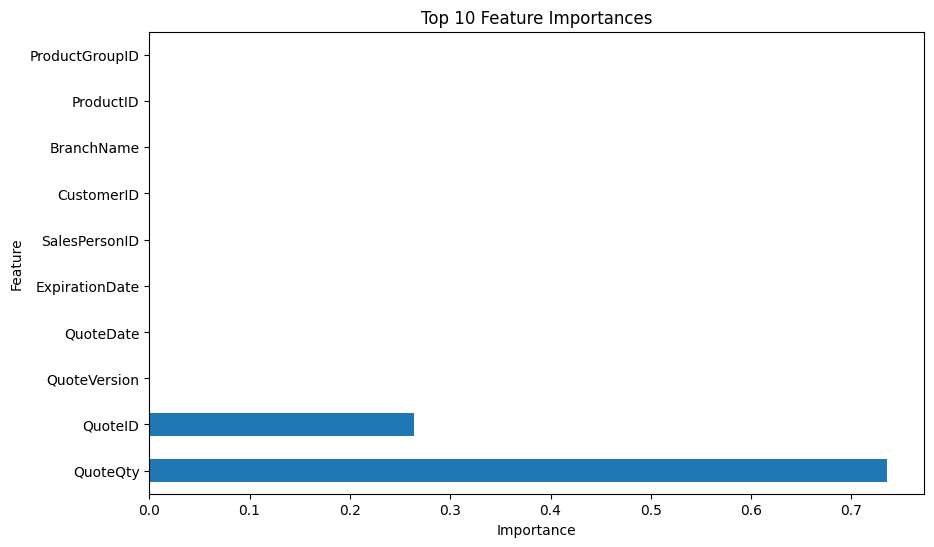


Decision Tree Rules:
|--- QuoteQty <= 1.00
|   |--- class: Lost
|--- QuoteQty >  1.00
|   |--- QuoteQty <= 1.00
|   |   |--- class: Won
|   |--- QuoteQty >  1.00
|   |   |--- QuoteQty <= 2.00
|   |   |   |--- class: Lost
|   |   |--- QuoteQty >  2.00
|   |   |   |--- QuoteID <= 1406480.00
|   |   |   |   |--- QuoteID <= 75904.50
|   |   |   |   |   |--- class: Won
|   |   |   |   |--- QuoteID >  75904.50
|   |   |   |   |   |--- class: Won
|   |   |   |--- QuoteID >  1406480.00
|   |   |   |   |--- QuoteID <= 1443925.50
|   |   |   |   |   |--- class: Lost
|   |   |   |   |--- QuoteID >  1443925.50
|   |   |   |   |   |--- class: Won



2

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv(r"C:\Users\nhail\Downloads\cleaned_quotes_data (1).csv")
print("Dataset Columns:", df.columns)

leakage_cols = ['OrderNumber', 'ConversionDate']
df = df.drop(columns=leakage_cols, errors='ignore')

# Define features and target (target remains as string "Won" and "Lost")
X = df.drop(columns=['QuoteStatus'], errors='ignore')
y = df['QuoteStatus']

# Identify categorical columns in X and apply Label Encoding
categorical_cols = X.select_dtypes(include=['object']).columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Split data into training and testing sets (80% train, 20% test) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# Initialize and train Decision Tree Classifier with a limited depth to avoid overfitting
clf = DecisionTreeClassifier(random_state=42, max_depth=5)
clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = clf.predict(X_test)


# Print Accuracy (four decimal places) and Classification Report
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("Classification Report:")
# We specify labels=["Lost", "Won"] to ensure the order (Lost -> 0, Won -> 1)
# 'digits=4' ensures four decimal places in the report
print(classification_report(y_test, y_pred, labels=["Lost", "Won"], digits=4))


# (Optional) Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=["Lost", "won"])
print("\nConfusion Matrix:")
print(cm)

# (Optional) Cross-Validation
cv_scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
print("\nCross-Validation Accuracy: %.2f ± %.2f" % (cv_scores.mean(), cv_scores.std()))


# (Optional) Visualize Feature Importances
feat_importances = pd.Series(clf.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


# (Optional) Print Decision Tree Rules
tree_rules = export_text(clf, feature_names=list(X.columns))
print("\nDecision Tree Rules:")
print(tree_rules)
2

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# 1. Load the dataset
df = pd.read_csv(r"C:\Users\nhail\Downloads\main_quotes_with_new_customer_tier.csv")

# Optional: Filter to only include "Won" and "Lost" quotes if needed
df = df[df["QuoteStatus"].isin(["Won", "Lost"])]

# 2. Drop leakage columns that could directly reveal the target outcome
leakage_cols = ['ConvertedToOrderNumber', 'ConversionDate']
df = df.drop(columns=leakage_cols, errors='ignore')

# 3. Define features and target
X = df.drop(columns=['QuoteStatus'], errors='ignore')
y = df['QuoteStatus']

# 4. Identify object columns and separate them based on cardinality
card_threshold = 100  # adjust threshold as needed
one_hot_cols = []
label_enc_cols = []

for col in X.select_dtypes(include=['object']).columns:
    nunique = X[col].nunique()
    if nunique <= card_threshold:
        one_hot_cols.append(col)
    else:
        label_enc_cols.append(col)

print("Columns to One-Hot Encode (low cardinality):", one_hot_cols)
print("Columns to Label Encode (high cardinality):", label_enc_cols)

# Apply One-Hot Encoding to low-cardinality columns
X_onehot = pd.get_dummies(X[one_hot_cols], drop_first=True)

# Apply Label Encoding to high-cardinality columns
for col in label_enc_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# Get numeric columns (if any)
numeric_cols = X.select_dtypes(include=['number']).columns.tolist()

# Combine all processed columns
X_processed = pd.concat([X[numeric_cols], X_onehot], axis=1)

# 5. Split data into training and testing sets (80% train, 20% test) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Set up a reduced hyperparameter grid for the Decision Tree to save resources
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': [None, 'sqrt']
}

# 7. Initialize GridSearchCV with limited parallelism and reduced CV folds
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,                 # reduce CV folds
    scoring='accuracy',
    n_jobs=1              # use a single job to limit resource usage
)
grid_search.fit(X_train, y_train)
print("Best Parameters from GridSearchCV:", grid_search.best_params_)

# 8. Use the best estimator from the grid search
best_clf = grid_search.best_estimator_
y_pred = best_clf.predict(X_test)

# 9. Evaluate the optimized model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nOptimized Decision Tree Accuracy: {accuracy:.4f}")
print("\nOptimized Classification Report:")
print(classification_report(y_test, y_pred, labels=["Lost", "Won"], digits=4))

# Optional: Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=["Lost", "Won"])
print("\nOptimized Confusion Matrix:")
print(cm)

# Optional: Cross-Validation on the entire dataset using the best model
cv_scores = cross_val_score(best_clf, X_processed, y, cv=3, scoring='accuracy')
print("Cross-Validation Accuracy: %.4f ± %.4f" % (cv_scores.mean(), cv_scores.std()))

# Optional: Print the decision tree rules for the optimized model
tree_rules = export_text(best_clf, feature_names=list(X_processed.columns))
print("\nDecision Tree Rules:")
print(tree_rules)

# Optional: Visualize Feature Importances
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(best_clf.feature_importances_, index=X_processed.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


C:\Users\nhail\AppData\Local\Temp\ipykernel_7536\1390837084.py:9: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\nhail\Downloads\main_quotes_with_new_customer_tier.csv")


Columns to One-Hot Encode (low cardinality): ['SalesPersonID', 'SalesPersonName', 'BranchName', 'Ship2State', 'ProductGroupID', 'UOM']
Columns to Label Encode (high cardinality): ['QuoteID', 'QuoteDate', 'ExpirationDate', 'CustomerID', 'CustomerName', 'Ship2City', 'ProductID']


KeyboardInterrupt: 